In [1]:
import numpy as np

class GridWorld:
    def __init__(self, stochastic=False):
        self.rows, self.cols = 3, 4
        self.wall = (1, 1)
        self.terminals = {(0, 3): 1, (1, 3): -1}
        self.actions = ["U", "D", "L", "R"]
        self.action_symbols = {"U": "↑", "D": "↓", "L": "←", "R": "→"}
        self.gamma = 0.9
        self.step = -0.01

        # Stochastic attributes
        self.stochastic = stochastic
        self.p_intended = 0.8
        self.p_side = 0.1

    def is_terminal(self, s):
        return s in self.terminals

    def move(self, s, a):
        if self.is_terminal(s):
            return s

        r, c = s

        if a == "U":
            r -= 1
        elif a == "D":
            r += 1
        elif a == "L":
            c -= 1
        elif a == "R":
            c += 1

        ns = (r, c)

        if (r < 0 or r >= self.rows or c < 0 or c >= self.cols or ns == self.wall):
            return s

        return ns

    def get_side_actions(self, a):
        """Returns the two side actions for a given action (for stochastic environment)"""
        if a == "U":
            return ("L", "R")
        if a == "D":
            return ("R", "L")
        if a == "L":
            return ("D", "U")
        if a == "R":
            return ("U", "D")

    def expected_value(self, V, s, a):
        """Calculate expected value for both deterministic and stochastic environments"""
        if not self.stochastic:
            # Deterministic case
            ns = self.move(s, a)
            if self.is_terminal(ns):
                return self.step + self.gamma * self.terminals[ns]
            else:
                nr, nc = ns
                return self.step + self.gamma * V[nr, nc]
        else:
            # Stochastic case
            left, right = self.get_side_actions(a)
            transitions = [
                (self.p_intended, a),
                (self.p_side, left),
                (self.p_side, right),
            ]

            value = 0
            for p, act in transitions:
                ns = self.move(s, act)
                if self.is_terminal(ns):
                    reward = self.terminals[ns]
                    value += p * (self.step + self.gamma * reward)
                else:
                    nr, nc = ns
                    value += p * (self.step + self.gamma * V[nr, nc])

            return value


def policy_evaluation(env, policy, V, theta=1e-5):
    """Evaluate a policy using iterative policy evaluation"""
    while True:
        delta = 0
        V_old = V.copy()

        for r in range(env.rows):
            for c in range(env.cols):
                s = (r, c)

                if s == env.wall:
                    continue

                if env.is_terminal(s):
                    V[r, c] = env.terminals[s]
                    continue

                a = policy[r, c]
                v = env.expected_value(V_old, s, a)

                delta = max(delta, abs(v - V[r, c]))
                V[r, c] = v

        if delta < theta:
            break

    return V


def policy_improvement(env, V, policy):
    """Improve policy based on current value function"""
    stable = True

    for r in range(env.rows):
        for c in range(env.cols):
            s = (r, c)

            if s == env.wall or env.is_terminal(s):
                continue

            old_action = policy[r, c]
            best_action = None
            best_value = -1e9

            for a in env.actions:
                v = env.expected_value(V, s, a)
                if v > best_value:
                    best_value = v
                    best_action = a

            policy[r, c] = best_action

            if old_action != best_action:
                stable = False

    return policy, stable


def policy_iteration(env):
    """Perform policy iteration to find optimal value function and policy"""
    V = np.zeros((env.rows, env.cols))
    policy = np.random.choice(env.actions, (env.rows, env.cols))

    iteration = 0
    while True:
        iteration += 1
        V = policy_evaluation(env, policy, V)
        policy, stable = policy_improvement(env, V, policy)

        if stable:
            break

    return V, policy, iteration


def print_results(env, V, policy, title):
    """Print formatted results"""
    print(f"\n{'='*60}")
    print(f"{title} ENVIRONMENT - POLICY ITERATION RESULTS")
    print(f"{'='*60}")
    print(f"Grid Size: {env.rows} x {env.cols}")
    print(f"Wall at: {env.wall}")
    print(f"Terminal states: {env.terminals}")
    print(f"Discount factor (γ): {env.gamma}")
    print(f"Step cost: {env.step}")
    if env.stochastic:
        print(f"Action success probability: {env.p_intended}")
        print(f"Action side probability: {env.p_side} each")

    print("\nValue Function:")
    print("-" * 40)
    for i in range(env.rows):
        row_str = "| "
        for j in range(env.cols):
            if (i, j) == env.wall:
                row_str += "   WALL   | "
            else:
                row_str += f"{V[i, j]:8.3f} | "
        print(row_str)

    print("\nOptimal Policy:")
    print("-" * 40)
    for i in range(env.rows):
        row_str = "| "
        for j in range(env.cols):
            if (i, j) == env.wall:
                row_str += "   WALL   | "
            elif (i, j) in env.terminals:
                val = env.terminals[(i, j)]
                row_str += f"  TERM{'+' if val>0 else '-'}{int(val)}  | "
            else:
                symbol = env.action_symbols[policy[i, j]]
                row_str += f"    {policy[i, j]} ({symbol})   | "
        print(row_str)


def compare_policies(env_det, policy_det, env_stoch, policy_stoch):
    """Compare policies between deterministic and stochastic environments"""
    print(f"\n{'='*60}")
    print("POLICY COMPARISON")
    print(f"{'='*60}")

    diff_count = 0
    for i in range(env_det.rows):
        for j in range(env_det.cols):
            if ((i, j) != env_det.wall and
                (i, j) not in env_det.terminals):
                det_action = policy_det[i, j]
                stoch_action = policy_stoch[i, j]

                if det_action != stoch_action:
                    diff_count += 1
                    det_symbol = env_det.action_symbols[det_action]
                    stoch_symbol = env_stoch.action_symbols[stoch_action]
                    print(f"State ({i},{j}): Deterministic={det_action} ({det_symbol}), "
                          f"Stochastic={stoch_action} ({stoch_symbol})")

    if diff_count == 0:
        print("✓ Policies are identical in both environments!")
    else:
        print(f"\n✗ Found {diff_count} state(s) with different policies")


# Main execution
if __name__ == "__main__":
    np.set_printoptions(precision=3, suppress=True)

    # Create environments
    print("Running Policy Iteration...")
    print("="*60)

    # Deterministic environment
    env_det = GridWorld(stochastic=False)
    V_det, policy_det, iter_det = policy_iteration(env_det)
    print_results(env_det, V_det, policy_det, "DETERMINISTIC")
    print(f"\nConverged in {iter_det} iterations")

    # Stochastic environment
    env_stoch = GridWorld(stochastic=True)
    V_stoch, policy_stoch, iter_stoch = policy_iteration(env_stoch)
    print_results(env_stoch, V_stoch, policy_stoch, "STOCHASTIC")
    print(f"\nConverged in {iter_stoch} iterations")

    # Compare policies
    compare_policies(env_det, policy_det, env_stoch, policy_stoch)

    # Show raw arrays
    print(f"\n{'='*60}")
    print("RAW NUMPY ARRAYS")
    print(f"{'='*60}")
    print("\nDeterministic Value Function:")
    print(V_det)
    print("\nDeterministic Policy:")
    print(policy_det)
    print("\nStochastic Value Function:")
    print(V_stoch)
    print("\nStochastic Policy:")
    print(policy_stoch)

Running Policy Iteration...

DETERMINISTIC ENVIRONMENT - POLICY ITERATION RESULTS
Grid Size: 3 x 4
Wall at: (1, 1)
Terminal states: {(0, 3): 1, (1, 3): -1}
Discount factor (γ): 0.9
Step cost: -0.01

Value Function:
----------------------------------------
|    0.702 |    0.791 |    0.890 |    1.000 | 
|    0.622 |    WALL   |    0.791 |   -1.000 | 
|    0.550 |    0.622 |    0.702 |    0.622 | 

Optimal Policy:
----------------------------------------
|     R (→)   |     R (→)   |     R (→)   |   TERM+1  | 
|     U (↑)   |    WALL   |     U (↑)   |   TERM--1  | 
|     U (↑)   |     R (→)   |     U (↑)   |     L (←)   | 

Converged in 5 iterations

STOCHASTIC ENVIRONMENT - POLICY ITERATION RESULTS
Grid Size: 3 x 4
Wall at: (1, 1)
Terminal states: {(0, 3): 1, (1, 3): -1}
Discount factor (γ): 0.9
Step cost: -0.01
Action success probability: 0.8
Action side probability: 0.1 each

Value Function:
----------------------------------------
|    0.611 |    0.721 |    0.835 |    1.000 | 
|    0.

Running Policy Iteration...

Deterministic: Converged in 4 iterations
Stochastic: Converged in 4 iterations

Creating visualizations...


/tmp/ipykernel_851/2440805160.py:312: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_851/2440805160.py:312: UserWarning: Glyph 129521 (\N{BRICK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_851/2440805160.py:312: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_851/2440805160.py:218: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_851/2440805160.py:218: UserWarning: Glyph 129521 (\N{BRICK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_851/2440805160.py:218: UserWarning: Glyph 128128 (\N{SKULL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core

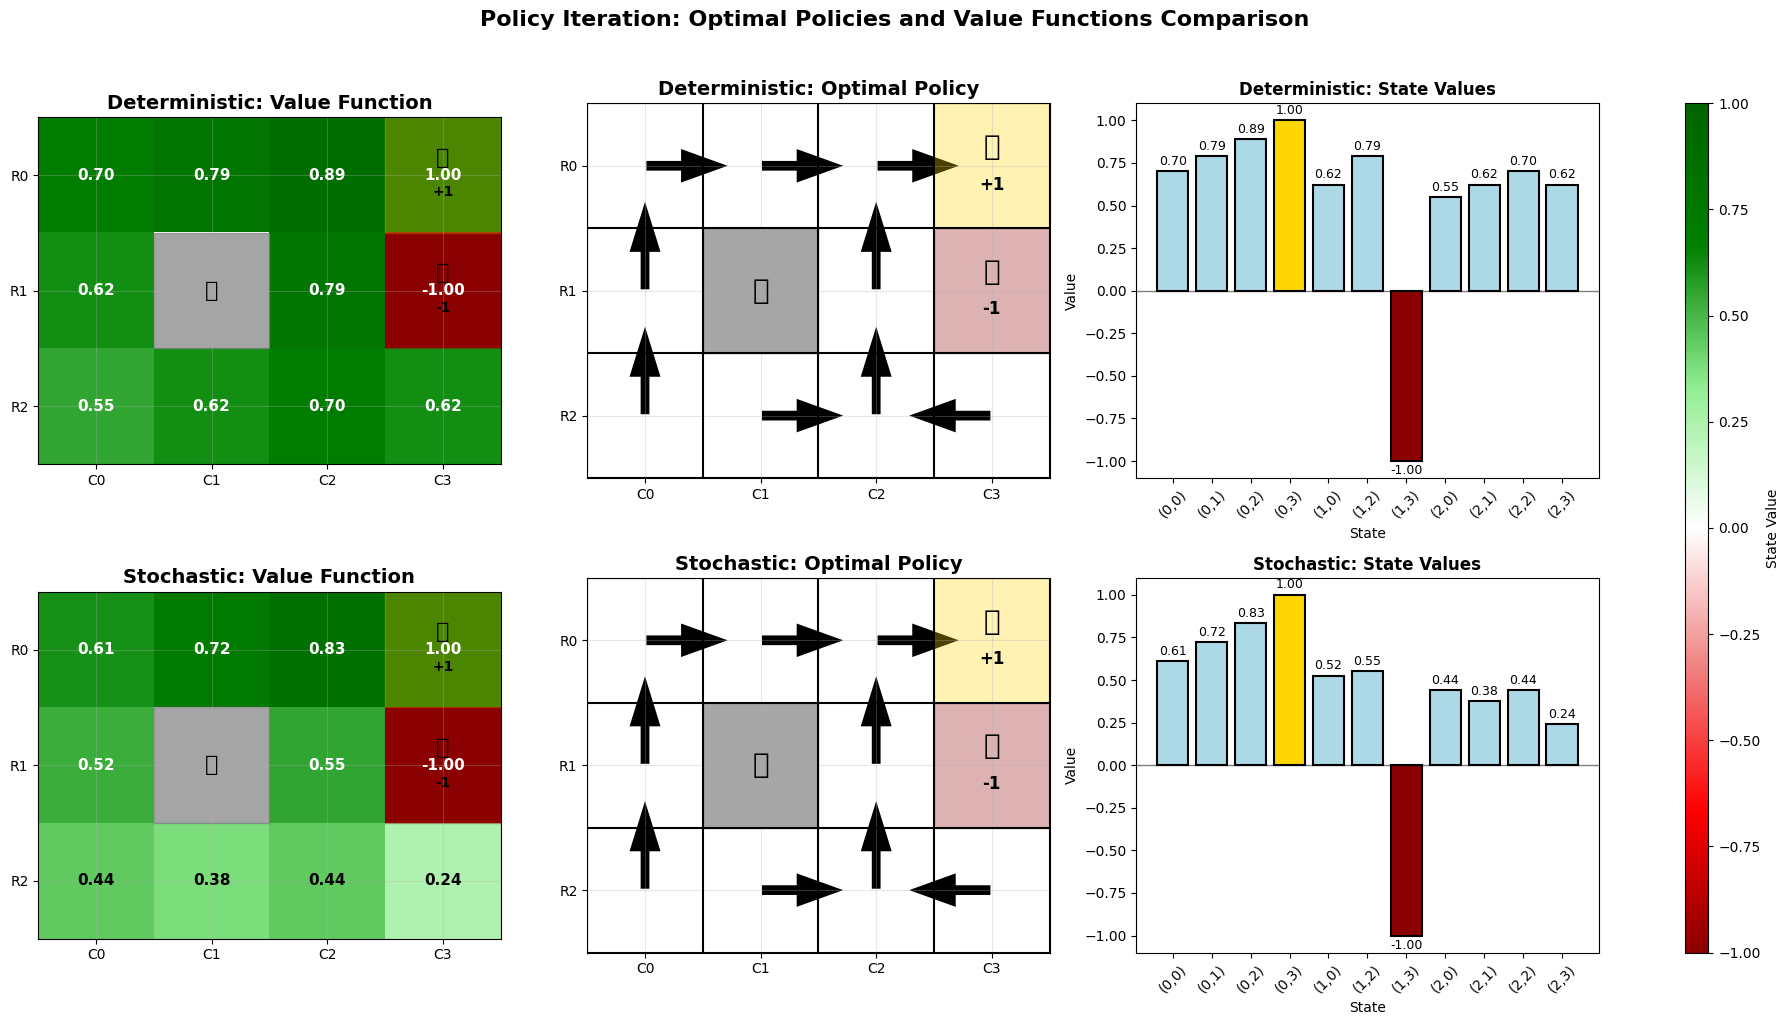

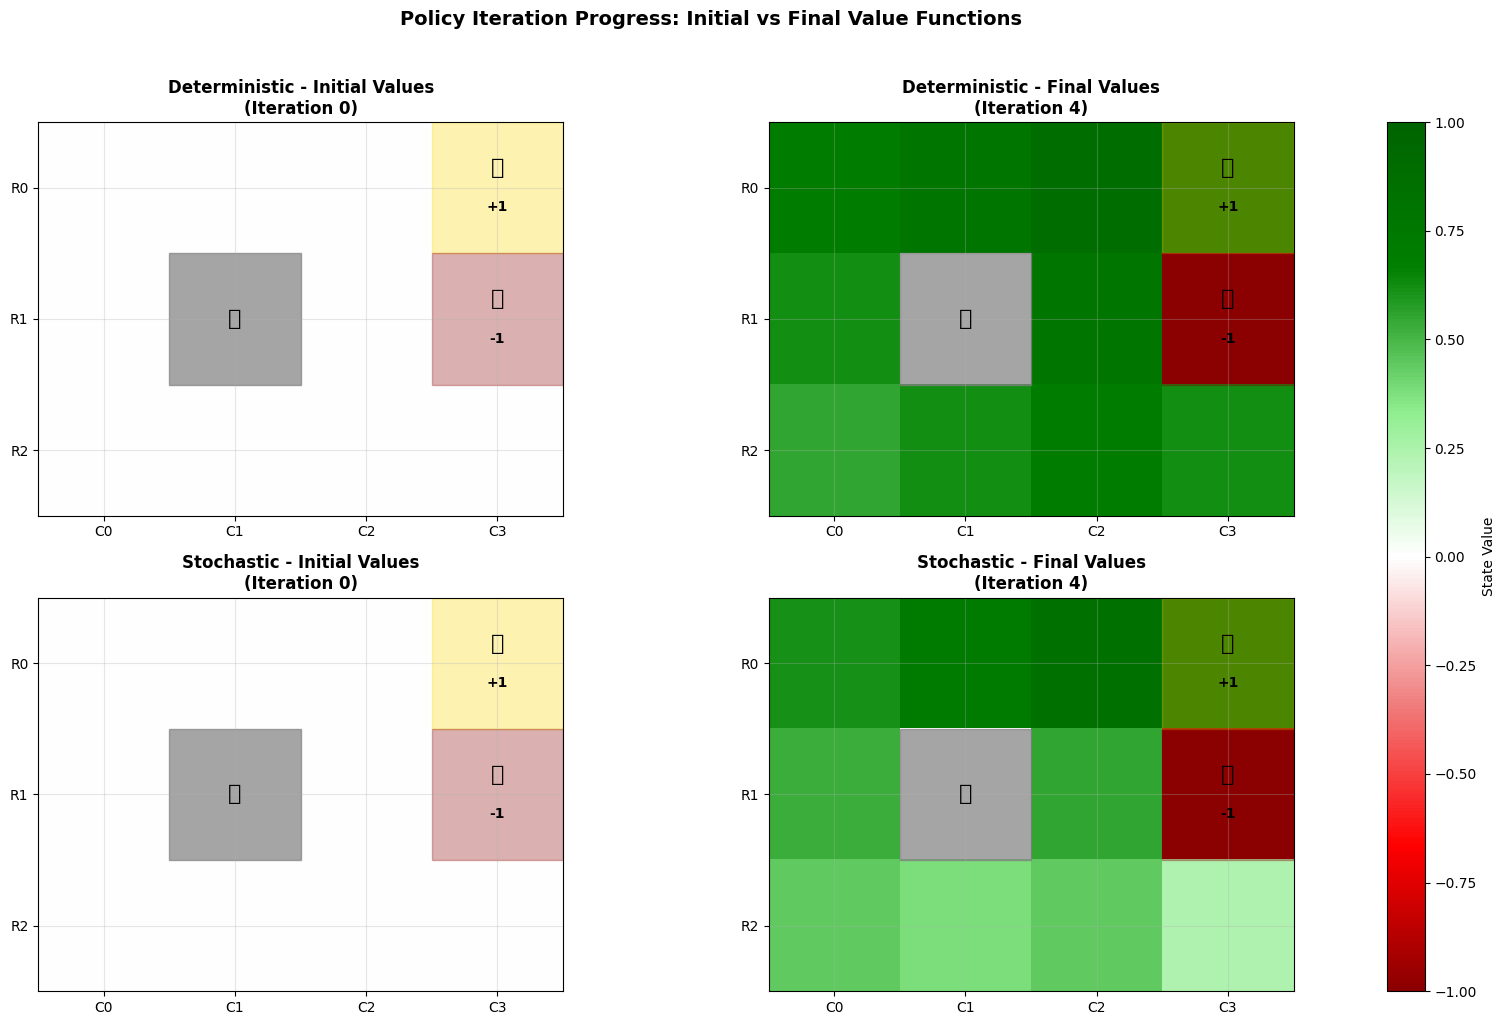

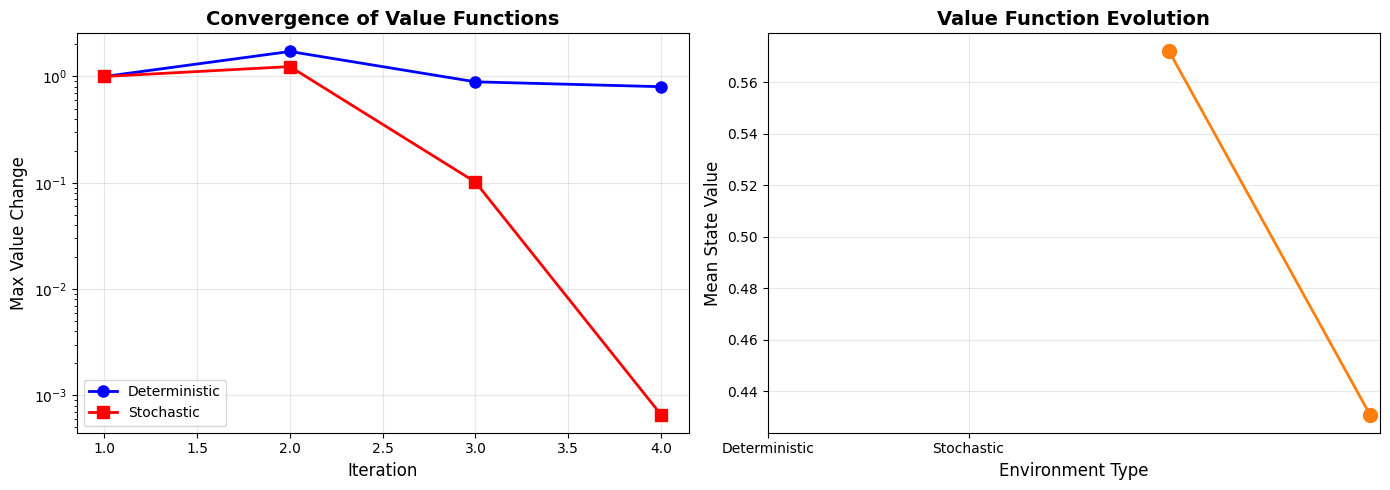

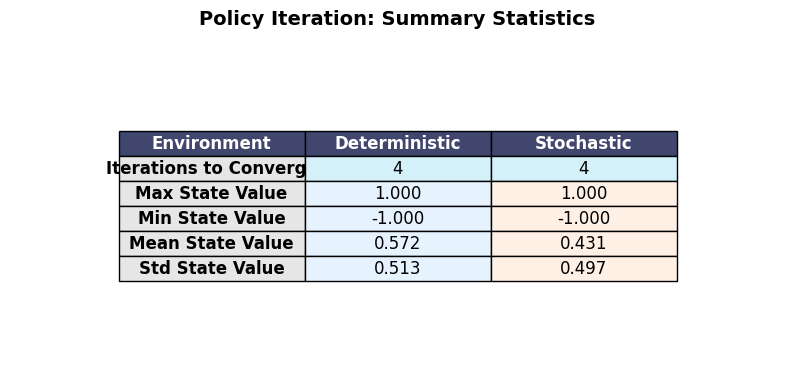


POLICY COMPARISON
✓ Policies are identical in both environments!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, Arrow, Circle
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

class GridWorld:
    def __init__(self, stochastic=False):
        self.rows, self.cols = 3, 4
        self.wall = (1, 1)
        self.terminals = {(0, 3): 1, (1, 3): -1}
        self.actions = ["U", "D", "L", "R"]
        self.action_symbols = {"U": "↑", "D": "↓", "L": "←", "R": "→"}
        self.action_names = {"U": "UP", "D": "DOWN", "L": "LEFT", "R": "RIGHT"}
        self.gamma = 0.9
        self.step = -0.01

        # Stochastic attributes
        self.stochastic = stochastic
        self.p_intended = 0.8
        self.p_side = 0.1

    def is_terminal(self, s):
        return s in self.terminals

    def move(self, s, a):
        if self.is_terminal(s):
            return s

        r, c = s

        if a == "U":
            r -= 1
        elif a == "D":
            r += 1
        elif a == "L":
            c -= 1
        elif a == "R":
            c += 1

        ns = (r, c)

        if (r < 0 or r >= self.rows or c < 0 or c >= self.cols or ns == self.wall):
            return s

        return ns

    def get_side_actions(self, a):
        """Returns the two side actions for a given action (for stochastic environment)"""
        if a == "U":
            return ("L", "R")
        if a == "D":
            return ("R", "L")
        if a == "L":
            return ("D", "U")
        if a == "R":
            return ("U", "D")

    def expected_value(self, V, s, a):
        """Calculate expected value for both deterministic and stochastic environments"""
        if not self.stochastic:
            # Deterministic case
            ns = self.move(s, a)
            if self.is_terminal(ns):
                return self.step + self.gamma * self.terminals[ns]
            else:
                nr, nc = ns
                return self.step + self.gamma * V[nr, nc]
        else:
            # Stochastic case
            left, right = self.get_side_actions(a)
            transitions = [
                (self.p_intended, a),
                (self.p_side, left),
                (self.p_side, right),
            ]

            value = 0
            for p, act in transitions:
                ns = self.move(s, act)
                if self.is_terminal(ns):
                    reward = self.terminals[ns]
                    value += p * (self.step + self.gamma * reward)
                else:
                    nr, nc = ns
                    value += p * (self.step + self.gamma * V[nr, nc])

            return value


def policy_evaluation(env, policy, V, theta=1e-5):
    """Evaluate a policy using iterative policy evaluation"""
    while True:
        delta = 0
        V_old = V.copy()

        for r in range(env.rows):
            for c in range(env.cols):
                s = (r, c)

                if s == env.wall:
                    continue

                if env.is_terminal(s):
                    V[r, c] = env.terminals[s]
                    continue

                a = policy[r, c]
                v = env.expected_value(V_old, s, a)

                delta = max(delta, abs(v - V[r, c]))
                V[r, c] = v

        if delta < theta:
            break

    return V


def policy_improvement(env, V, policy):
    """Improve policy based on current value function"""
    stable = True

    for r in range(env.rows):
        for c in range(env.cols):
            s = (r, c)

            if s == env.wall or env.is_terminal(s):
                continue

            old_action = policy[r, c]
            best_action = None
            best_value = -1e9

            for a in env.actions:
                v = env.expected_value(V, s, a)
                if v > best_value:
                    best_value = v
                    best_action = a

            policy[r, c] = best_action

            if old_action != best_action:
                stable = False

    return policy, stable


def policy_iteration(env):
    """Perform policy iteration to find optimal value function and policy"""
    V = np.zeros((env.rows, env.cols))
    policy = np.random.choice(env.actions, (env.rows, env.cols))

    iteration = 0
    history = {'values': [V.copy()], 'policies': [policy.copy()]}

    while True:
        iteration += 1
        V = policy_evaluation(env, policy, V)
        policy, stable = policy_improvement(env, V, policy)

        history['values'].append(V.copy())
        history['policies'].append(policy.copy())

        if stable:
            break

    return V, policy, iteration, history


def visualize_policy_iteration(env_det, history_det, env_stoch, history_stoch):
    """Visualize the policy iteration process"""
    fig = plt.figure(figsize=(16, 10))
    gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 0.05])

    # Custom colormap for value function
    colors = ['darkred', 'red', 'lightcoral', 'white', 'lightgreen', 'green', 'darkgreen']
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=256)

    # Plot initial and final value functions for deterministic
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    # Initial value function
    im1 = ax1.imshow(history_det['values'][0], cmap=cmap, vmin=-1, vmax=1, aspect='equal')
    ax1.set_title(f'Deterministic - Initial Values\n(Iteration 0)', fontsize=12, fontweight='bold')
    _format_grid(ax1, env_det, history_det['policies'][0], show_policy=False)

    # Final value function
    im2 = ax2.imshow(history_det['values'][-1], cmap=cmap, vmin=-1, vmax=1, aspect='equal')
    ax2.set_title(f'Deterministic - Final Values\n(Iteration {len(history_det["values"])-1})',
                  fontsize=12, fontweight='bold')
    _format_grid(ax2, env_det, history_det['policies'][-1], show_policy=False)

    # Plot initial and final value functions for stochastic
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])

    # Initial value function
    im3 = ax3.imshow(history_stoch['values'][0], cmap=cmap, vmin=-1, vmax=1, aspect='equal')
    ax3.set_title(f'Stochastic - Initial Values\n(Iteration 0)', fontsize=12, fontweight='bold')
    _format_grid(ax3, env_stoch, history_stoch['policies'][0], show_policy=False)

    # Final value function
    im4 = ax4.imshow(history_stoch['values'][-1], cmap=cmap, vmin=-1, vmax=1, aspect='equal')
    ax4.set_title(f'Stochastic - Final Values\n(Iteration {len(history_stoch["values"])-1})',
                  fontsize=12, fontweight='bold')
    _format_grid(ax4, env_stoch, history_stoch['policies'][-1], show_policy=False)

    # Add colorbar
    cax = fig.add_subplot(gs[:, 2])
    plt.colorbar(im4, cax=cax, label='State Value')

    plt.suptitle('Policy Iteration Progress: Initial vs Final Value Functions',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


def _format_grid(ax, env, policy, show_policy=True):
    """Helper function to format grid with proper labels and symbols"""
    ax.set_xticks(np.arange(env.cols))
    ax.set_yticks(np.arange(env.rows))
    ax.set_xticklabels([f'C{j}' for j in range(env.cols)])
    ax.set_yticklabels([f'R{i}' for i in range(env.rows)])
    ax.grid(True, alpha=0.3)

    # Add value text and special symbols
    for i in range(env.rows):
        for j in range(env.cols):
            if (i, j) == env.wall:
                ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gray', alpha=0.7))
                ax.text(j, i, '🧱', ha='center', va='center', fontsize=16)
            elif (i, j) in env.terminals:
                if env.terminals[(i, j)] > 0:
                    ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gold', alpha=0.3))
                    ax.text(j, i-0.15, '🏆', ha='center', va='center', fontsize=16)
                    ax.text(j, i+0.15, '+1', ha='center', va='center', fontsize=10, fontweight='bold')
                else:
                    ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='darkred', alpha=0.3))
                    ax.text(j, i-0.15, '💀', ha='center', va='center', fontsize=16)
                    ax.text(j, i+0.15, '-1', ha='center', va='center', fontsize=10, fontweight='bold')
            elif show_policy and policy is not None:
                action = policy[i, j]
                symbol = env.action_symbols[action]
                ax.text(j, i, symbol, ha='center', va='center', fontsize=24, fontweight='bold')


def visualize_optimal_policies(env_det, V_det, policy_det, env_stoch, V_stoch, policy_stoch):
    """Create a comprehensive visualization of optimal policies and value functions"""
    fig = plt.figure(figsize=(18, 10))
    gs = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.05])

    # Custom colormap
    colors = ['darkred', 'red', 'lightcoral', 'white', 'lightgreen', 'green', 'darkgreen']
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=256)

    # Deterministic - Value Function Heatmap
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(V_det, cmap=cmap, vmin=-1, vmax=1, aspect='equal')
    ax1.set_title('Deterministic: Value Function', fontsize=14, fontweight='bold')
    _format_grid(ax1, env_det, None, show_policy=False)

    # Add value text
    for i in range(env_det.rows):
        for j in range(env_det.cols):
            if (i, j) != env_det.wall:
                color = 'black' if abs(V_det[i, j]) < 0.5 else 'white'
                ax1.text(j, i, f'{V_det[i, j]:.2f}', ha='center', va='center',
                        fontsize=11, fontweight='bold', color=color)

    # Deterministic - Policy Visualization
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.set_title('Deterministic: Optimal Policy', fontsize=14, fontweight='bold')
    _draw_policy_grid(ax2, env_det, policy_det)

    # Deterministic - State Values Bar Chart
    ax3 = fig.add_subplot(gs[0, 2])
    _plot_value_bars(ax3, env_det, V_det, "Deterministic")

    # Stochastic - Value Function Heatmap
    ax4 = fig.add_subplot(gs[1, 0])
    im4 = ax4.imshow(V_stoch, cmap=cmap, vmin=-1, vmax=1, aspect='equal')
    ax4.set_title('Stochastic: Value Function', fontsize=14, fontweight='bold')
    _format_grid(ax4, env_stoch, None, show_policy=False)

    # Add value text
    for i in range(env_stoch.rows):
        for j in range(env_stoch.cols):
            if (i, j) != env_stoch.wall:
                color = 'black' if abs(V_stoch[i, j]) < 0.5 else 'white'
                ax4.text(j, i, f'{V_stoch[i, j]:.2f}', ha='center', va='center',
                        fontsize=11, fontweight='bold', color=color)

    # Stochastic - Policy Visualization
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.set_title('Stochastic: Optimal Policy', fontsize=14, fontweight='bold')
    _draw_policy_grid(ax5, env_stoch, policy_stoch)

    # Stochastic - State Values Bar Chart
    ax6 = fig.add_subplot(gs[1, 2])
    _plot_value_bars(ax6, env_stoch, V_stoch, "Stochastic")

    # Colorbar
    cax = fig.add_subplot(gs[:, 3])
    plt.colorbar(im4, cax=cax, label='State Value')

    plt.suptitle('Policy Iteration: Optimal Policies and Value Functions Comparison',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


def _draw_policy_grid(ax, env, policy):
    """Draw a beautiful policy grid with arrows"""
    ax.set_xlim(-0.5, env.cols - 0.5)
    ax.set_ylim(env.rows - 0.5, -0.5)
    ax.set_xticks(np.arange(env.cols))
    ax.set_yticks(np.arange(env.rows))
    ax.set_xticklabels([f'C{j}' for j in range(env.cols)])
    ax.set_yticklabels([f'R{i}' for i in range(env.rows)])
    ax.grid(True, alpha=0.3)

    # Draw grid lines
    for i in range(env.rows + 1):
        ax.axhline(y=i - 0.5, color='black', linewidth=1.5)
    for j in range(env.cols + 1):
        ax.axvline(x=j - 0.5, color='black', linewidth=1.5)

    # Add policy arrows and special symbols
    arrow_props = dict(facecolor='black', edgecolor='white', linewidth=2, width=0.1, head_width=0.3)

    for i in range(env.rows):
        for j in range(env.cols):
            if (i, j) == env.wall:
                ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gray', alpha=0.7))
                ax.text(j, i, '🧱', ha='center', va='center', fontsize=20)
            elif (i, j) in env.terminals:
                if env.terminals[(i, j)] > 0:
                    ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='gold', alpha=0.3))
                    ax.text(j, i-0.15, '🏆', ha='center', va='center', fontsize=20)
                    ax.text(j, i+0.15, '+1', ha='center', va='center', fontsize=12, fontweight='bold')
                else:
                    ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=True, color='darkred', alpha=0.3))
                    ax.text(j, i-0.15, '💀', ha='center', va='center', fontsize=20)
                    ax.text(j, i+0.15, '-1', ha='center', va='center', fontsize=12, fontweight='bold')
            else:
                action = policy[i, j]
                if action == "U":
                    ax.arrow(j, i, 0, -0.3, **arrow_props)
                elif action == "D":
                    ax.arrow(j, i, 0, 0.3, **arrow_props)
                elif action == "L":
                    ax.arrow(j, i, -0.3, 0, **arrow_props)
                elif action == "R":
                    ax.arrow(j, i, 0.3, 0, **arrow_props)


def _plot_value_bars(ax, env, V, title):
    """Create a bar chart of state values"""
    states = []
    values = []
    colors = []

    for i in range(env.rows):
        for j in range(env.cols):
            if (i, j) != env.wall:
                states.append(f'({i},{j})')
                values.append(V[i, j])
                if (i, j) in env.terminals:
                    colors.append('gold' if env.terminals[(i, j)] > 0 else 'darkred')
                else:
                    colors.append('lightblue' if V[i, j] >= 0 else 'lightcoral')

    bars = ax.bar(states, values, color=colors, edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.set_title(f'{title}: State Values', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')
    ax.set_xlabel('State')
    ax.tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02 * (1 if height >= 0 else -1),
                f'{val:.2f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)


def visualize_convergence(history_det, history_stoch):
    """Visualize the convergence of value functions during policy iteration"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Calculate max changes per iteration
    det_changes = []
    stoch_changes = []

    for i in range(1, len(history_det['values'])):
        change = np.max(np.abs(history_det['values'][i] - history_det['values'][i-1]))
        det_changes.append(change)

    for i in range(1, len(history_stoch['values'])):
        change = np.max(np.abs(history_stoch['values'][i] - history_stoch['values'][i-1]))
        stoch_changes.append(change)

    # Plot convergence
    axes[0].plot(range(1, len(det_changes)+1), det_changes, 'b-o', linewidth=2, markersize=8, label='Deterministic')
    axes[0].plot(range(1, len(stoch_changes)+1), stoch_changes, 'r-s', linewidth=2, markersize=8, label='Stochastic')
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('Max Value Change', fontsize=12)
    axes[0].set_title('Convergence of Value Functions', fontsize=14, fontweight='bold')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Plot value function heatmap evolution
    iterations = [0, len(history_det['values'])-1]
    labels = ['Initial', 'Final']

    for idx, (det_val, stoch_val) in enumerate(zip(
        [history_det['values'][i] for i in iterations],
        [history_stoch['values'][i] for i in iterations]
    )):
        axes[1].plot([idx*2, idx*2+1], [np.mean(det_val[det_val != 0]), np.mean(stoch_val[stoch_val != 0])],
                    'o-', linewidth=2, markersize=10,
                    label=f'{labels[idx]} (Det/Stoch)' if idx == 0 else "")

    axes[1].set_xlabel('Environment Type', fontsize=12)
    axes[1].set_ylabel('Mean State Value', fontsize=12)
    axes[1].set_title('Value Function Evolution', fontsize=14, fontweight='bold')
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Deterministic', 'Stochastic'])
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def create_dashboard(env_det, V_det, policy_det, env_stoch, V_stoch, policy_stoch,
                     history_det, history_stoch):
    """Create a comprehensive dashboard with all visualizations"""
    # Create all figures
    fig1 = visualize_optimal_policies(env_det, V_det, policy_det, env_stoch, V_stoch, policy_stoch)
    fig2 = visualize_policy_iteration(env_det, history_det, env_stoch, history_stoch)
    fig3 = visualize_convergence(history_det, history_stoch)

    # Create a summary statistics table
    fig4, ax = plt.subplots(figsize=(10, 4))
    ax.axis('tight')
    ax.axis('off')

    # Prepare summary data
    summary_data = [
        ['Environment', 'Deterministic', 'Stochastic'],
        ['Iterations to Converge', len(history_det['values'])-1, len(history_stoch['values'])-1],
        ['Max State Value', f'{np.max(V_det[V_det != 0]):.3f}', f'{np.max(V_stoch[V_stoch != 0]):.3f}'],
        ['Min State Value', f'{np.min(V_det[V_det != 0]):.3f}', f'{np.min(V_stoch[V_stoch != 0]):.3f}'],
        ['Mean State Value', f'{np.mean(V_det[V_det != 0]):.3f}', f'{np.mean(V_stoch[V_stoch != 0]):.3f}'],
        ['Std State Value', f'{np.std(V_det[V_det != 0]):.3f}', f'{np.std(V_stoch[V_stoch != 0]):.3f}'],
    ]

    table = ax.table(cellText=summary_data, loc='center', cellLoc='center', colWidths=[0.2, 0.2, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)

    # Style the table
    for i in range(len(summary_data)):
        for j in range(len(summary_data[0])):
            cell = table[(i, j)]
            if i == 0:
                cell.set_facecolor('#40466e')
                cell.set_text_props(weight='bold', color='white')
            elif j == 0:
                cell.set_facecolor('#e6e6e6')
                cell.set_text_props(weight='bold')
            elif i > 0 and j > 0:
                if i == 1:  # Iterations row
                    cell.set_facecolor('#d4f1f9')
                elif j == 1:  # Deterministic column
                    cell.set_facecolor('#e6f3ff')
                else:  # Stochastic column
                    cell.set_facecolor('#fff0e6')

    ax.set_title('Policy Iteration: Summary Statistics', fontsize=14, fontweight='bold', pad=20)

    return fig1, fig2, fig3, fig4


# Main execution
if __name__ == "__main__":
    np.set_printoptions(precision=3, suppress=True)

    # Create environments
    print("Running Policy Iteration...")
    print("="*60)

    # Deterministic environment
    env_det = GridWorld(stochastic=False)
    V_det, policy_det, iter_det, history_det = policy_iteration(env_det)

    # Stochastic environment
    env_stoch = GridWorld(stochastic=True)
    V_stoch, policy_stoch, iter_stoch, history_stoch = policy_iteration(env_stoch)

    # Print results
    print(f"\nDeterministic: Converged in {iter_det} iterations")
    print(f"Stochastic: Converged in {iter_stoch} iterations")

    # Create all visualizations
    print("\nCreating visualizations...")

    # Dashboard with all plots
    fig1, fig2, fig3, fig4 = create_dashboard(
        env_det, V_det, policy_det,
        env_stoch, V_stoch, policy_stoch,
        history_det, history_stoch
    )

    # Show all figures
    plt.show()

    # Print policy comparison
    print("\n" + "="*60)
    print("POLICY COMPARISON")
    print("="*60)

    diff_count = 0
    for i in range(env_det.rows):
        for j in range(env_det.cols):
            if ((i, j) != env_det.wall and (i, j) not in env_det.terminals):
                if policy_det[i, j] != policy_stoch[i, j]:
                    diff_count += 1
                    print(f"State ({i},{j}): Det={policy_det[i, j]} ({env_det.action_symbols[policy_det[i, j]]}), "
                          f"Stoch={policy_stoch[i, j]} ({env_stoch.action_symbols[policy_stoch[i, j]]})")

    if diff_count == 0:
        print("✓ Policies are identical in both environments!")
    else:
        print(f"\n✗ Found {diff_count} state(s) with different policies")